# AI-Assisted Computing with Large Language Models

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/medAI-hands-on/blob/main/notebooks/03_llm_assisted_computing.ipynb)

This notebook demonstrates how to leverage Large Language Models (LLMs) for medical text analysis and research assistance.

**Chapter 22**: Arvid Lundervold *Artificial Intelligence and Computational Medicine: A Hands-on Approach*  
Section 5 - AI-Assisted Computing with Large Language Models

version: 2026-07-19

---

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Understand** LLM capabilities and limitations in medical contexts
2. **Use** Hugging Face transformers for text processing
3. **Implement** medical text summarization and named entity recognition
4. **Apply** prompt engineering techniques for medical queries
5. **Evaluate** when to use LLMs vs. traditional NLP approaches

---

## Prerequisites

- Basic Python knowledge
- Some understanding of NLP concepts
- **Runtime**: ~20-30 minutes to read and run

<details>
<summary>🔧 <b>Technical Requirements</b></summary>

- **Python 3.8+** with PyTorch 2.0+ and Transformers 4.30+
- **GPU recommended**: Speeds up model inference significantly
- **Memory**: ~8GB RAM minimum for smaller models
- **Storage**: ~2GB for model downloads (cached after first use)
- **Network**: Required for downloading models from Hugging Face Hub
</details>

<details>
<summary>⚠️ <b>Important Notes on Medical LLM Use</b></summary>

- **LLM outputs require human validation** — never use as authoritative medical advice
- **Never input Protected Health Information (PHI)** into cloud-based models without appropriate safeguards
- **Generated code should always be reviewed** before execution in clinical contexts
- For privacy-sensitive applications, consider **local/on-premise models** (Llama, Mistral, etc.)
</details>


---

## Background and Rationale

### Why Large Language Models in Computational Medicine?

While medical imaging (Notebook 01) and multimodal data fusion (Notebook 02) address the analysis of *structured* clinical data, a vast portion of medical knowledge exists as **unstructured text**—clinical notes, research literature, pathology reports, discharge summaries, and treatment guidelines. **Large Language Models (LLMs)** have emerged as powerful tools for processing, understanding, and generating such text at scale.

The role of LLMs in computational medicine is multifaceted:

- **Clinical text analysis**: Extracting structured information from free-text reports (symptoms, diagnoses, medications)
- **Literature synthesis**: Summarizing research findings from thousands of publications
- **Clinical decision support**: Providing contextual information at the point of care
- **Code and workflow assistance**: Accelerating biomedical research through code generation and debugging
- **Patient communication**: Generating readable summaries of complex medical information

<details>
<summary>📖 <b>Clinical Context: The Burden of Medical Documentation</b></summary>

Physicians spend a significant portion of their time on documentation—estimates suggest **2 hours of EHR (Electronic Health Record) work for every 1 hour of patient care**. LLMs offer potential solutions:

- **Automated note summarization**: Condensing lengthy patient histories into actionable summaries
- **Report generation**: Drafting radiology or pathology reports from structured findings
- **Information retrieval**: Quickly finding relevant patient information buried in years of records
- **Translation**: Converting medical jargon into patient-friendly language

However, these applications require careful validation, as errors in medical text processing can have serious clinical consequences.
</details>

---

### Connection to Previous Notebooks: The Three Pillars of Medical AI

This notebook completes a natural progression through the fundamental modalities of medical AI:

```
┌─────────────────────────────────────────────────────────────────────────────┐
│  NOTEBOOK 01              │  NOTEBOOK 02              │  NOTEBOOK 03        │
│  Medical Imaging          │  Multimodal Integration   │  LLM-Assisted       │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  ┌─────────────────┐     ┌─────────────────────┐     ┌─────────────────┐    │
│  │  VISUAL DATA    │     │  STRUCTURED DATA    │     │  TEXT DATA      │    │
│  │(Pixels & Voxels)│     │  (Features/Tables)  │     │  (Language)     │    │
│  └────────┬────────┘     └──────────┬──────────┘     └────────┬────────┘    │
│           │                         │                         │             │
│           ▼                         ▼                         ▼             │
│  ┌─────────────────┐     ┌─────────────────────┐     ┌─────────────────┐    │
│  │  Deep Learning  │     │  Attention-Based    │     │  Transformer    │    │
│  │  (3D U-Net)     │ ──▶ │  Fusion             │ ──▶ │  Models (LLMs)  │    │
│  └─────────────────┘     └─────────────────────┘     └─────────────────┘    │
│           │                         │                         │             │
│           ▼                         ▼                         ▼             │
│  ┌─────────────────┐     ┌─────────────────────┐     ┌─────────────────┐    │
│  │  Segmentation   │     │  Patient            │     │  Text Analysis  │    │
│  │  Masks          │     │  Stratification     │     │  & Generation   │    │
│  └─────────────────┘     └─────────────────────┘     └─────────────────┘    │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
```

**The notebooks build upon each other conceptually:**

| Notebook | Data Type | Key Challenge | AI Approach |
|----------|-----------|---------------|-------------|
| **01: Imaging** | 3D MRI volumes | Pixel-level annotation | Convolutional networks (U-Net) |
| **02: Multimodal** | Features + clinical data | Heterogeneous fusion | Attention mechanisms |
| **03: LLM** | Clinical text, code | Semantic understanding | Transformers / language models |

Together, they represent the spectrum of data types encountered in modern computational medicine—from structured imaging to heterogeneous features to unstructured language.


---

### LLMs in Medical Research: Capabilities and Considerations

Modern LLMs (e.g., GPT-4/5, Claude, Llama, Gemini) offer powerful capabilities, but their use in medical contexts requires careful consideration. Recent systematic reviews provide evidence-based assessments of current maturity levels:

#### Potential Applications (Evidence-Based Assessment)

| Application | Example | Maturity | Evidence |
|-------------|---------|----------|----------|
| **Literature review** | Summarizing papers on drug interactions | ⬤⬤⬤○○ Emerging | Tools like Elicit, Consensus in active use; humans outperform on full systematic reviews [1] |
| **Code assistance** | Generating Python scripts for analysis | ⬤⬤⬤⬤○ Maturing | Widely adopted in production (Cursor, Copilot, Claude Code); ~37% on novel research code [2] |
| **Report drafting*** | Creating first-draft radiology reports | ⬤⬤○○○ Research | Vision-LLMs achieve ~35% vs expert 86%; harmful outputs in up to 45% of cases [3] |
| **Clinical Q&A** | Answering patient medication questions | ⬤⬤○○○ Research | Only a few studies of real-world clinical LLM deployment as of 2025 [4] |
| **Diagnostic support** | Suggesting differential diagnoses | ⬤⬤○○○ Research | GPT-4 achieves 56-72% diagnostic accuracy; below expert physicians [5] |




<details>
<summary>📚 <b>Supporting Literature</b></summary>

**[1]** Gou et al. (2025). *Human researchers are superior to large language models in writing a medical systematic review in a comparative multitask assessment.* Nature Scientific Reports. [doi:10.1038/s41598-025-28993-5](https://www.nature.com/articles/s41598-025-28993-5)

**[2]** Huang et al. (2025). *ResearchCodeBench: Benchmarking LLMs on Implementing Novel Machine Learning Research Code.* arXiv:2506.02314. [arxiv.org/abs/2506.02314](https://arxiv.org/abs/2506.02314)

**[3]** Liu et al. (2025). *Evaluating the diagnostic accuracy of vision language models for neuroradiological image interpretation.* npj Digital Medicine. [doi:10.1038/s41746-025-02047-6](https://www.nature.com/articles/s41746-025-02047-6)

**[4]** Benary et al. (2025). *Large language models in real-world clinical workflows: a systematic review.* Frontiers in Digital Health. [doi:10.3389/fdgth.2025.1659134](https://www.frontiersin.org/articles/10.3389/fdgth.2025.1659134)

**[5]** Horiuchi et al. (2025). *A systematic review and meta-analysis of GPT-based differential diagnostic accuracy in radiological cases.* Frontiers in Radiology. [doi:10.3389/fradi.2025.1670517](https://www.frontiersin.org/articles/10.3389/fradi.2025.1670517)

See also: Reis et al. (2025). *A systematic review of large language model (LLM) evaluations in clinical medicine.* BMC Medical Informatics. [doi:10.1186/s12911-025-02954-4](https://bmcmedinformdecismak.biomedcentral.com/articles/10.1186/s12911-025-02954-4)
</details>



---

#### Critical Limitations

> **⚠️ Important Considerations for Medical LLM Use:**
>
> 1. **Hallucinations**: LLMs can generate *factually incorrect information* - though error rates are comparable to non-expert physicians (~5-10% diagnostic error); mitigations include RAG grounding, chain-of-thought reasoning, calibrated confidence scores (flagging uncertain outputs), and expert oversight
>
> 2. **Knowledge currency**: Base models have *training cutoffs*, but *RAG* and *agentic tools* can retrieve and cross-validate current information across multiple sources (databases, guidelines, literature) - often more systematically than time-constrained humans
>
> 3. **Privacy concerns**: Protected Health Information (PHI) requires safeguards - *local/on-premise models* (Llama, Mistral, etc.) enable privacy-preserving deployment; *cloud-based models* need appropriate data agreements and anonymization
>
> 4. **Liability and accountability**: Emerging frameworks address responsibility - EU AI Act, FDA AI/ML guidance, human-in-the-loop requirements (clinician retains final responsibility), and audit trails documenting AI contributions
>
> 5. **Bias amplification**: LLMs may perpetuate biases in training data - mitigations include fine-tuning on diverse/curated datasets, RLHF alignment, bias auditing across demographic groups, and continuous monitoring in deployment

**Best practice**: Treat LLM outputs as *drafts* requiring human expert validation, never as authoritative medical advice.

---

#### *) Recent Technological Achievements: Mitigating Hallucination with Reinforcement Learning

A critical barrier to "upgrading" the status of **report drafting** has historically been the fear of hallucinations - generative AI models inventing findings that do not exist in the image. Evidence from early 2026 shows that this problem is being effectively reduced through the application of **Reinforcement Learning (RL)**, specifically in frameworks like Microsoft's **UniRG (Universal Report Generation)**.

Unlike previous models that were trained using "proxy text-generation objectives" (optimizing for the statistical likelihood of the next word), UniRG utilizes multimodal reinforcement learning to align model training with "real-world radiology practice". This involves a feedback loop where the model is explicitly rewarded for **clinical correctness** and penalized for errors, rather than just being rewarded for linguistic fluency.
<!-- 
  TEMPORARY: Image embedded as base64 for Colab compatibility with private repo.
  When publishing to public repo arvidl/medAI-hands-on, replace the base64 img tag below with:
  <img src="https://raw.githubusercontent.com/arvidl/medAI-hands-on/main/assets/unirg_RL_framework_2026.png" alt="UniRG Framework" width="700">
-->
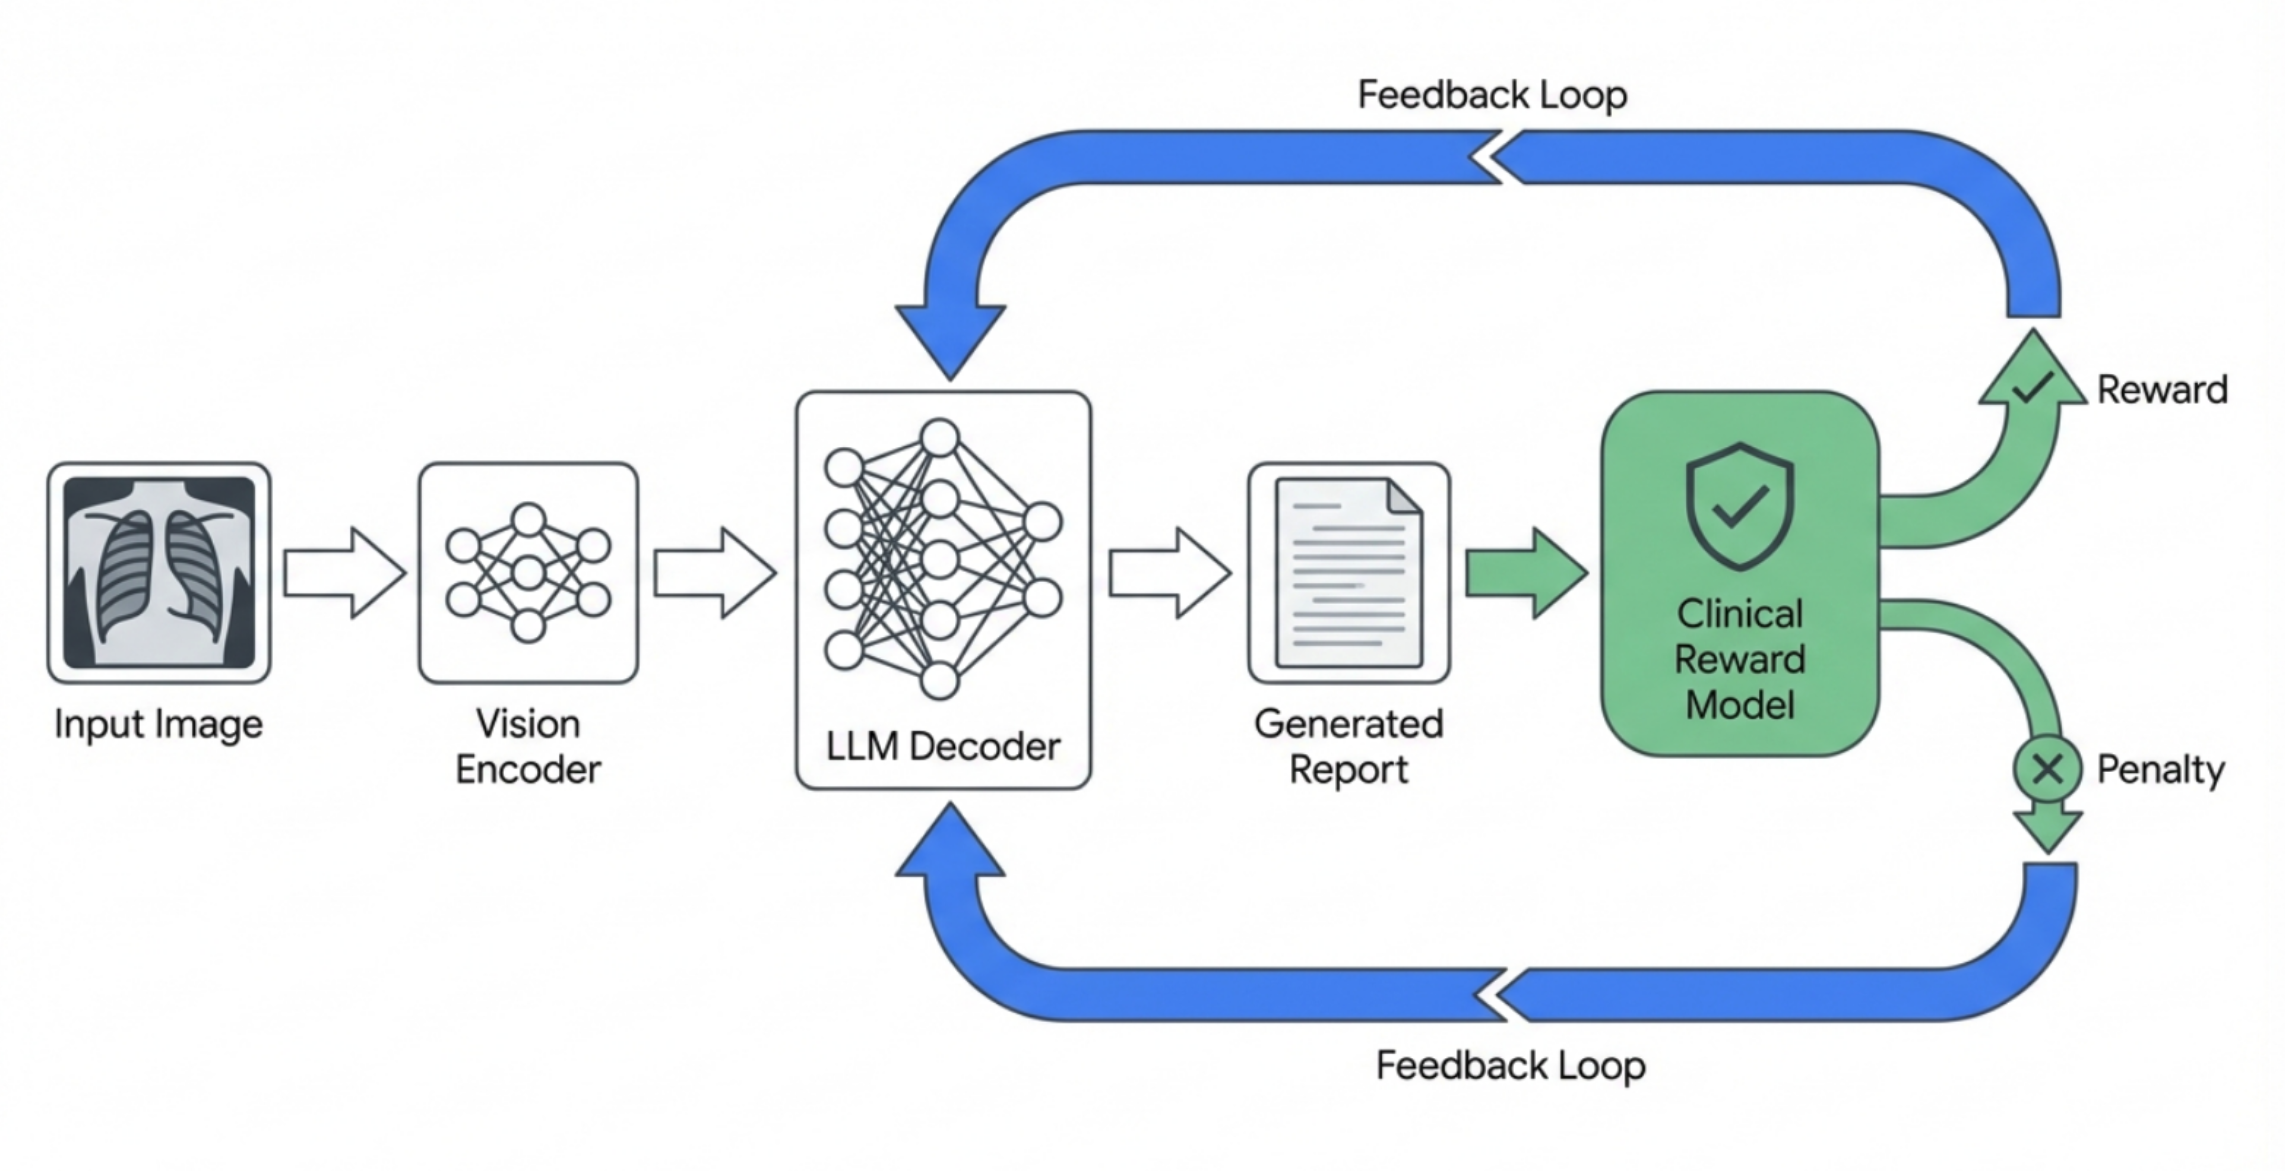


*Microsoft's UniRG framework (2026) aligns AI training with real-world radiology practice. Unlike standard LLMs that optimize for text fluency, UniRG uses clinical reward signals to penalize hallucinations and reward accurate diagnostic findings.* (Zhang et al., 2026. [UniRG: Scaling medical imaging report generation with multimodal reinforcement learning](https://arxiv.org/abs/2601.17151). arXiv:2601.17151)

### Prospective: The 2026 Maturity Matrix

The evidence gathered from the 2024–2026 period unequivocally supports the "upgrading" of the maturation status for all five application domains. These technologies have successfully navigated the "Valley of Death" between pilot studies and widespread adoption. They are characterized now by robust adoption statistics, clear regulatory pathways, and performance benchmarks that often exceed human capabilities in specific tasks.

**Likely 2026 Maturation Status Upgrades**

| Application Domain | Probable 2026 Status | Key Justification (Evidence) |
|--------------------|------------------------|------------------------------|
| **Literature Review** | Operational Support | 85% screening accuracy and 40% time reduction in systematic reviews. Emergence of PRISMA-trAIce standards for governance. |
| **Code Assistance** | Ubiquitous Infrastructure | 84% developer adoption globally. 74% autonomous fix rate on SWE-bench Verified. Shift to agentic coding. |
| **Report Drafting** | Regulated Production | >1,000 FDA authorizations in radiology. Reinforcement Learning (UniRG) effectively mitigates clinical hallucinations. |
| **Clinical Q&A** | Deployed with Supervision | 75% draft rate in major health systems (NYU). "Empathy Engines" reduce negative patient emotions by ~70%. |
| **Diagnostic Support** | Advanced Decision Support | 94% accuracy vs. 70.5% human in NEJM Image Challenge. Emergence of Reasoning Agents (CoT) over simple probability models. |

The trajectory for the remainder of 2026 and into 2027 will likely focus on the "Orchestration" of these mature tools—connecting the Literature Review agent to the Diagnostic Support agent to create learning health systems that continuously update their knowledge base. For now, however, the verdict is clear: **the tools are ready**. The challenge has shifted from *building the technology* to *managing its integration*.

<details>
<summary>📚 <b>Supporting Literature for Prospective "upgrading" of the maturation status for all five application domains</b></summary>

1. **Literature Review**
Metric: 85% screening accuracy and 40% time reduction.

Source: [Cypris.ai Insights: The Best AI Tools for Scientific Literature Review in 2026](https://www.cypris.ai/insights/11-best-ai-tools-for-scientific-literature-review-in-2026). This industry report synthesizes 2024–2025 data indicating that AI-assisted screening achieves 85% accuracy in identifying relevant papers while reducing overall review time by approximately 40%.

Metric: Emergence of PRISMA-trAIce standards.

Source: [Holst et al. (2025). Transparent Reporting of AI in Systematic Literature Reviews: Development of the PRISMA-trAIce Checklist](https://ai.jmir.org/2025/1/e80247). Published in JMIR AI, this paper establishes the first formal reporting guideline extension for AI in evidence synthesis.

2. **Code Assistance**
Metric: 84% developer adoption globally.

Source: [JetBrains](https://www.infoworld.com/article/4077352/85-of-developers-use-ai-regularly-jetbrains-survey.html) & [Stack Overflow Developer Surveys (2025)](https://survey.stackoverflow.co/2025/ai/). Aggregated data from these major industry surveys indicates that approximately 84% of developers now use or plan to use AI tools, with over 50% using them daily.

Metric: 74% autonomous fix rate on SWE-bench Verified.

Source: [mini-SWE-agent: The 100-line AI agent](https://mini-swe-agent.com/latest/) (Princeton University/SWE-bench Team, 2025). This research demonstrates that streamlined agentic scaffolds using models like Claude 3.5 Sonnet or GPT-4o can achieve a 74% resolution rate on the verified subset of the SWE-bench software engineering benchmark.

3. **Report Drafting**
Metric: >1,000 FDA authorizations in radiology.

Source: [The Imaging Wire / FDA AI-Enabled Device Reporting (Late 2025)](https://theimagingwire.com/2025/12/10/ai-enabled-medical-devices-granted-fda-marketing-authorization/). Recent regulatory data confirms that the FDA has authorized over 1,000 AI-enabled radiology devices, accounting for nearly 78% of all AI medical device approvals.

Metric: Reinforcement Learning (UniRG) mitigates hallucinations.

Source: [Zhang et al. (Microsoft Research, 2026). Scaling medical imaging report generation with multimodal reinforcement learning](https://arxiv.org/abs/2601.17151). This paper introduces the UniRG framework, which uses clinical reward signals to substantially reduce clinically significant errors compared to standard text-generation models.

4. **Clinical Q&A**
Metric: 75% draft rate in major health systems.

Source: [NYU Langone Health GenAI implementation study](https://pmc.ncbi.nlm.nih.gov/articles/PMC11756645/) and [systematic review of GenAI for patient messages](https://www.nature.com/articles/s44401-025-00032-5). Studies analyzing patient message workflows (including data from NYU Langone Health and Stanford Health Care) report high rates of draft generation coverage (75%) and varying clinician utilization (approx. 20%), demonstrating technical maturity but necessary human-in-the-loop supervision.

Metric: "Empathy Engines" reduce negative emotions by ~70%.

Source: [Wan et al. (2024). Outpatient reception via collaboration between nurses and a large language model](https://www.nature.com/articles/s41591-024-03148-7). Published in Nature Medicine, this randomized controlled trial found that a site-specific LLM chatbot (SSPEC) reduced negative patient emotions from 7.8% to 2.4% (a ~69% reduction) compared to nurse-only interactions.

5. **Diagnostic Support**
Metric: 94% accuracy vs. 70.5% human in NEJM Image Challenge.

Source: [Zhou et al. (2026). Diagnostic performance of large language models on the NEJM Image Challenge](https://www.frontiersin.org/journals/medicine/articles/10.3389/fmed.2025.1709413/full). Published in Frontiers in Medicine, this study benchmarked the OpenAI o4-mini-high model against physicians and medical students, finding the AI achieved 94% accuracy compared to 70.5% for attending physicians.
</details>

---

### What This Notebook Covers

In this notebook, we explore practical applications of LLMs in biomedical research contexts:

1. **Text summarization**: Condensing medical abstracts and clinical text
2. **Named entity recognition**: Extracting medical concepts from unstructured text
3. **Code generation**: Using LLMs as programming assistants for data analysis
4. **Prompt engineering**: Techniques for effective medical queries

We use **open-source models** from Hugging Face (rather than proprietary APIs) to demonstrate concepts that can be run locally without privacy concerns - an important consideration for biomedical applications.

---

## 1. Environment Setup

In [1]:
# Check if running in Google Colab
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab - installing dependencies...")
    %pip install -q transformers accelerate sentencepiece
    %pip install -q chromadb sentence-transformers
    print("✓ Dependencies installed")
else:
    # For local execution, add parent directory to path
    sys.path.insert(0, '..')

print(f"Python version: {sys.version}")

Python version: 3.11.15 (main, Apr 14 2026, 14:28:36) [Clang 22.1.3 ]


In [2]:
# Core imports
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random
import warnings
warnings.filterwarnings('ignore')

# Deep learning and NLP
import torch
from transformers import pipeline, AutoTokenizer, AutoModelForSeq2SeqLM
from transformers import AutoModelForCausalLM, set_seed as hf_set_seed

# ============================================================================
# IMPORT STRATEGY: Use src/ modules locally, define inline for Colab
# ============================================================================
if IN_COLAB:
    # Define get_device inline for Colab
    def get_device(force_cpu_for_3d=False):
        """Get the best available device (CUDA, MPS, or CPU)."""
        if torch.cuda.is_available():
            device = torch.device("cuda")
            print(f"Using CUDA: {torch.cuda.get_device_name(0)}")
        elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
            if force_cpu_for_3d:
                device = torch.device("cpu")
                print("Using CPU (MPS available but 3D ops not fully supported)")
            else:
                device = torch.device("mps")
                print("Using Apple Silicon MPS (with CPU fallback for unsupported ops)")
        else:
            device = torch.device("cpu")
            print("Using CPU")
        return device
else:
    # For local execution, import from src modules
    from src.data_utils import get_device

# ============================================================================
# REPRODUCIBILITY: Set all random seeds for reproducible results
# ============================================================================
SEED = 42

def set_seed(seed: int = 42):
    """Set all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # Also set Hugging Face transformers seed
    hf_set_seed(seed)

set_seed(SEED)
print(f"Random seed set to: {SEED}")
print(f"PyTorch version: {torch.__version__}")

Random seed set to: 42
PyTorch version: 2.13.0+cu130


In [3]:
# Get device
device = get_device()

# Check for TPU (Colab TPU runtime)
TPU_AVAILABLE = False
try:
    import torch_xla.core.xla_model as xm
    TPU_AVAILABLE = True
    print("⚠️ TPU detected but Hugging Face pipelines have limited TPU support.")
    print("   Recommend: Use Colab GPU runtime (Runtime → Change runtime type → GPU)")
except ImportError:
    pass

# Helper function for Hugging Face pipeline device selection
# Pipelines use: 0 for CUDA, "mps" for Apple Silicon, -1 for CPU
def get_pipeline_device():
    """Get device specification for Hugging Face pipelines."""
    if torch.cuda.is_available():
        return 0  # CUDA GPU 0 (Colab GPU, NVIDIA)
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return "mps"  # Apple Silicon
    else:
        return -1  # CPU (or TPU fallback - pipelines don't support TPU directly)

PIPELINE_DEVICE = get_pipeline_device()

# Print device info
print(f"\nDevice configuration:")
print(f"  PyTorch device: {device}")
print(f"  Pipeline device: {PIPELINE_DEVICE}")
if IN_COLAB:
    if torch.cuda.is_available():
        print(f"  ✓ Colab GPU runtime detected")
    else:
        print(f"  ⚠️ No GPU - for faster inference, use: Runtime → Change runtime type → GPU")

# For LLMs, check GPU memory
if torch.cuda.is_available():
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"  GPU memory: {gpu_mem:.1f} GB")
    if gpu_mem < 8:
        print("  ⚠️ Limited GPU memory - using smaller models")

Using CUDA: NVIDIA RTX A5000 Laptop GPU

Device configuration:
  PyTorch device: cuda
  Pipeline device: 0
  GPU memory: 16.8 GB


## 2. Sample Medical Texts

We'll use sample medical abstracts and clinical text snippets for demonstration. In practice, you would use your own research documents or publicly available medical literature.

In [4]:
# Sample medical abstracts for demonstration
SAMPLE_ABSTRACTS = [
    {
        "title": "Deep Learning for Brain Tumor Segmentation",
        "abstract": """Background: Accurate segmentation of brain tumors from MRI scans is crucial for 
        diagnosis, treatment planning, and monitoring. Deep learning methods have shown promising 
        results in automating this task. Methods: We developed a 3D U-Net architecture trained on 
        the BraTS dataset consisting of 1,251 multiparametric MRI scans. The network was trained 
        using Dice loss with data augmentation including random rotations, flips, and intensity 
        variations. Results: Our method achieved a mean Dice score of 0.89 for whole tumor, 0.83 
        for tumor core, and 0.79 for enhancing tumor on the validation set. The model processes 
        a complete brain volume in under 2 seconds on a standard GPU. Conclusions: Deep learning 
        enables accurate, fast, and reproducible brain tumor segmentation that could support 
        clinical workflows and reduce inter-observer variability."""
    },
    {
        "title": "Multimodal Learning in Precision Medicine",
        "abstract": """Precision medicine requires integration of diverse data modalities including 
        imaging, genomics, and clinical variables. We present a multimodal deep learning framework 
        that combines radiomics features extracted from CT scans with genomic profiles and clinical 
        data to predict treatment response in non-small cell lung cancer patients. Using a cohort 
        of 422 patients, our attention-based fusion model achieved an AUC of 0.82 compared to 
        0.71 for imaging-only and 0.68 for genomics-only models. The attention mechanism revealed 
        that imaging features dominated predictions for early-stage tumors while genomic features 
        were more important for advanced disease. This work demonstrates the value of multimodal 
        integration for personalized treatment selection."""
    },
    {
        "title": "Large Language Models in Clinical Documentation",
        "abstract": """Large language models (LLMs) have potential applications in clinical 
        documentation, including summarization and information extraction. We evaluated GPT-4 
        and clinical-domain fine-tuned models on summarizing discharge notes from 500 hospital 
        admissions. Human evaluators rated summaries for accuracy, completeness, and clinical 
        relevance. Fine-tuned models achieved 87% accuracy compared to 79% for general-purpose 
        LLMs. However, both exhibited occasional hallucinations requiring human oversight. 
        We recommend LLMs as assistive tools with mandatory clinician review rather than 
        autonomous documentation systems."""
    }
]

print(f"Loaded {len(SAMPLE_ABSTRACTS)} sample abstracts")
for i, item in enumerate(SAMPLE_ABSTRACTS):
    print(f"  {i+1}. {item['title']}")

Loaded 3 sample abstracts
  1. Deep Learning for Brain Tumor Segmentation
  2. Multimodal Learning in Precision Medicine
  3. Large Language Models in Clinical Documentation


## 3. Text Summarization

### Clinical Motivation

Medical professionals face an overwhelming volume of literature—over **5 million new articles** are published annually. Text summarization helps clinicians and researchers:

- **Rapid literature triage**: Quickly assess relevance of papers during systematic reviews
- **Patient record summarization**: Condense lengthy patient histories into actionable summaries
- **Report generation**: Create concise summaries of radiology or pathology findings

<details>
<summary>📖 <b>How Abstractive Summarization Works</b></summary>

Unlike **extractive summarization** (selecting key sentences verbatim), **abstractive summarization** generates new text that captures the essence of the original. Models like BART and T5 are trained on document-summary pairs to learn this mapping.

**BART (Bidirectional and Auto-Regressive Transformers)** uses:
1. A corrupted input (noising) during training
2. An encoder-decoder architecture to reconstruct the original
3. Fine-tuning on summarization datasets (CNN/DailyMail, XSum)

For medical text, models can be further fine-tuned on biomedical corpora (PubMed, clinical notes) to improve domain-specific performance.
</details>

---

We use a pre-trained **BART-large-CNN** model to condense medical abstracts. This demonstrates practical summarization for literature review and rapid content assessment.

In [5]:
# Load summarization model
# Using BART-large-CNN for text summarization
# Note: Newer transformers versions may not have "summarization" as a pipeline task,
# so we load the model and tokenizer directly for maximum compatibility
print("Loading summarization model...")

from transformers import BartForConditionalGeneration, BartTokenizer

summarizer_model = BartForConditionalGeneration.from_pretrained("facebook/bart-large-cnn")
summarizer_tokenizer = BartTokenizer.from_pretrained("facebook/bart-large-cnn")

# Move model to appropriate device
summarizer_model = summarizer_model.to(device)
summarizer_model.eval()

print(f"Model loaded on {device}!")

Loading summarization model...


[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

Model loaded on cuda!


In [6]:
def summarize_text(text, max_length=100, min_length=30):
    """Summarize a text using the loaded BART model."""
    # Clean up whitespace
    text = " ".join(text.split())
    
    # Tokenize input
    inputs = summarizer_tokenizer(
        text, 
        return_tensors="pt", 
        max_length=1024, 
        truncation=True
    ).to(device)
    
    # Generate summary
    with torch.no_grad():
        summary_ids = summarizer_model.generate(
            inputs["input_ids"],
            max_length=max_length,
            min_length=min_length,
            num_beams=4,
            length_penalty=2.0,
            early_stopping=True
        )
    
    # Decode and return
    summary = summarizer_tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    return summary

In [7]:
# Summarize the sample abstracts
print("=" * 60)
print("MEDICAL ABSTRACT SUMMARIZATION")
print("=" * 60)

for item in SAMPLE_ABSTRACTS:
    print(f"\n📄 {item['title']}")
    print("-" * 40)
    
    original = item['abstract']
    summary = summarize_text(original)
    
    print(f"Original ({len(original.split())} words):")
    print(f"  {original[:200]}...")
    print(f"\nSummary ({len(summary.split())} words):")
    print(f"  {summary}")
    print()

MEDICAL ABSTRACT SUMMARIZATION

📄 Deep Learning for Brain Tumor Segmentation
----------------------------------------
Original (124 words):
  Background: Accurate segmentation of brain tumors from MRI scans is crucial for 
        diagnosis, treatment planning, and monitoring. Deep learning methods have shown promising 
        results in a...

Summary (34 words):
  We developed a 3D U-Net architecture trained on the BraTS dataset consisting of 1,251 multiparametric MRI scans. The network was trained using Dice loss with data augmentation including random rotations, flips, and intensity variations.


📄 Multimodal Learning in Precision Medicine
----------------------------------------
Original (103 words):
  Precision medicine requires integration of diverse data modalities including 
        imaging, genomics, and clinical variables. We present a multimodal deep learning framework 
        that combines ...

Summary (46 words):
  We present a multimodal deep learning framework that com

## 4. Text Classification

### Clinical Motivation

Automated text classification enables systematic organization of medical documents at scale:

- **Literature categorization**: Automatically tag papers by topic, methodology, or disease area
- **Clinical note classification**: Identify note types (progress notes, discharge summaries, consults)
- **Triage and routing**: Route patient messages to appropriate specialists
- **Sentiment/urgency detection**: Flag high-priority communications

<details>
<summary>📖 <b>Zero-Shot Classification Explained</b></summary>

Traditional classifiers require labeled training data for each category. **Zero-shot classification** can classify text into *arbitrary categories* without task-specific training:

1. **Natural Language Inference (NLI)**: The model is trained to determine if a "hypothesis" is entailed by a "premise"
2. **Template matching**: Each category becomes a hypothesis (e.g., "This text is about {category}")
3. **Probability scoring**: The model scores how likely each hypothesis is given the input text

**Example**:
- Input: "Patient presents with chest pain and shortness of breath"
- Candidate labels: ["cardiology", "pulmonology", "neurology"]
- Model evaluates: "This text is about cardiology" → High probability

This approach is powerful for exploratory analysis when predefined categories don't exist.
</details>

---

We use **zero-shot classification** with BART-MNLI to categorize medical texts without task-specific training—useful for organizing research literature or clinical notes.

In [8]:
# Load zero-shot classification pipeline
print("Loading classification model...")
classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=PIPELINE_DEVICE  # Supports CUDA, MPS, or CPU
)
print("Model loaded!")

Loading classification model...


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Model loaded!


In [9]:
# Define candidate labels for classification
candidate_labels = [
    "medical imaging",
    "genomics and molecular biology",
    "clinical trials",
    "drug discovery",
    "health informatics",
    "natural language processing"
]

# Classify each abstract
print("=" * 60)
print("ZERO-SHOT TEXT CLASSIFICATION")
print("=" * 60)

for item in SAMPLE_ABSTRACTS:
    result = classifier(
        item['abstract'][:500],  # Limit length
        candidate_labels,
        multi_label=True
    )
    
    print(f"\n📄 {item['title']}")
    print("-" * 40)
    print("Top categories:")
    for label, score in zip(result['labels'][:3], result['scores'][:3]):
        print(f"  • {label}: {score:.2%}")

ZERO-SHOT TEXT CLASSIFICATION

📄 Deep Learning for Brain Tumor Segmentation
----------------------------------------
Top categories:
  • medical imaging: 98.36%
  • health informatics: 77.14%
  • clinical trials: 2.53%

📄 Multimodal Learning in Precision Medicine
----------------------------------------
Top categories:
  • medical imaging: 96.84%
  • genomics and molecular biology: 17.70%
  • health informatics: 10.38%

📄 Large Language Models in Clinical Documentation
----------------------------------------
Top categories:
  • natural language processing: 38.36%
  • health informatics: 13.49%
  • clinical trials: 3.00%


## 5. Named Entity Recognition

### Clinical Motivation

**Named Entity Recognition (NER)** extracts structured information from unstructured clinical text—a critical step in building clinical NLP pipelines:

- **Medication extraction**: Identify drug names, dosages, frequencies from prescription notes
- **Diagnosis coding**: Extract disease mentions for ICD coding
- **Adverse event detection**: Find mentions of symptoms, side effects, complications
- **Temporal reasoning**: Extract dates, durations, and temporal relationships

<details>
<summary>📖 <b>Medical NER: Challenges and Approaches</b></summary>

Medical NER is more challenging than general-domain NER due to:

| Challenge | Example |
|-----------|---------|
| **Abbreviations** | "pt c/o SOB" = "patient complains of shortness of breath" |
| **Synonyms** | "heart attack" = "MI" = "myocardial infarction" |
| **Negation** | "no evidence of pneumonia" (negative finding) |
| **Uncertainty** | "possible malignancy" vs "confirmed malignancy" |
| **Context dependence** | "discharge" (hospital discharge vs wound discharge) |

**Specialized medical NER models** (BioBERT, ClinicalBERT, PubMedBERT) are pre-trained on biomedical corpora and fine-tuned for entity extraction. For production use, consider:
- **scispaCy**: Scientific/biomedical NER pipelines
- **MedCAT**: Clinical concept annotation
- **BERN2**: Biomedical entity recognition and normalization
</details>

---

We extract key entities from medical text—conditions, treatments, measurements—using transformer-based NER models.

In [10]:
# Simple entity extraction using pattern matching
# (In production, use specialized biomedical NER models like BioBERT)

import re

def extract_medical_entities(text):
    """Extract common medical entities from text."""
    entities = {
        'metrics': [],
        'methods': [],
        'diseases': []
    }
    
    # Extract metrics (numbers with units or percentages)
    metric_patterns = [
        r'(\d+\.?\d*\s*%)',
        r'(AUC\s*(?:of\s*)?\d+\.?\d*)',
        r'(Dice\s*(?:score\s*)?(?:of\s*)?\d+\.?\d*)',
        r'(\d+\.?\d*\s*(?:seconds?|minutes?|hours?))',
        r'(\d+\s*(?:patients?|subjects?|samples?))'
    ]
    
    for pattern in metric_patterns:
        matches = re.findall(pattern, text, re.IGNORECASE)
        entities['metrics'].extend(matches)
    
    # Extract methods (common ML/medical terms)
    methods = ['U-Net', 'deep learning', 'CNN', 'transformer', 'attention',
               'MRI', 'CT', 'PET', 'radiomics', 'genomics', 'multimodal']
    for method in methods:
        if method.lower() in text.lower():
            entities['methods'].append(method)
    
    # Extract diseases/conditions
    diseases = ['tumor', 'cancer', 'glioma', 'lung cancer', 'brain tumor']
    for disease in diseases:
        if disease.lower() in text.lower():
            entities['diseases'].append(disease)
    
    return entities

In [11]:
# Extract entities from sample abstracts
print("=" * 60)
print("NAMED ENTITY EXTRACTION")
print("=" * 60)

for item in SAMPLE_ABSTRACTS:
    entities = extract_medical_entities(item['abstract'])
    
    print(f"\n📄 {item['title']}")
    print("-" * 40)
    for entity_type, values in entities.items():
        if values:
            unique_values = list(set(values))[:5]
            print(f"  {entity_type.capitalize()}: {', '.join(unique_values)}")

NAMED ENTITY EXTRACTION

📄 Deep Learning for Brain Tumor Segmentation
----------------------------------------
  Metrics: 2 seconds, Dice score of 0.89
  Methods: deep learning, MRI, CT, U-Net
  Diseases: tumor, brain tumor

📄 Multimodal Learning in Precision Medicine
----------------------------------------
  Metrics: 422 patients, AUC of 0.82
  Methods: radiomics, attention, deep learning, genomics, multimodal
  Diseases: lung cancer, cancer, tumor

📄 Large Language Models in Clinical Documentation
----------------------------------------
  Metrics: 87%, 79%
  Methods: CT


## 6. Code Generation Assistance

### Accelerating Biomedical Research

LLMs have transformed software development, with **84% of developers** now using AI coding assistants (Stack Overflow, 2025). For biomedical researchers, this means:

- **Faster prototyping**: Generate boilerplate for survival analysis, image preprocessing, statistical tests
- **Learning tool**: Understand unfamiliar libraries by asking for annotated examples
- **Debugging assistance**: Explain error messages and suggest fixes
- **Documentation**: Generate docstrings, comments, and README files

<details>
<summary>📖 <b>Code Generation: Best Practices</b></summary>

**What LLMs do well:**
- Boilerplate and template code
- Standard library usage (pandas, numpy, sklearn)
- Well-documented APIs (matplotlib, seaborn)
- Common patterns (data loading, preprocessing, visualization)

**What requires caution:**
- Novel algorithms or cutting-edge research code (~37% accuracy on research-level tasks)
- Security-critical code (authentication, encryption)
- Performance-critical optimizations
- Domain-specific statistical methods (verify assumptions!)

**Recommended workflow:**
1. **Prompt clearly**: Specify language, libraries, input/output formats
2. **Request explanations**: Ask the model to explain its reasoning
3. **Review thoroughly**: Check logic, edge cases, and assumptions
4. **Test rigorously**: Unit tests, integration tests, validation on known data
5. **Iterate**: Refine based on test results
</details>

---

Below are **code templates** for common medical data analysis tasks. In practice, these would be generated by an LLM and then **reviewed and tested** before use.

In [12]:
# Example: Code templates for common medical data analysis tasks
# These would typically be generated by an LLM but are shown here as examples

CODE_TEMPLATES = {
    "survival_analysis": '''
# Survival Analysis with Kaplan-Meier
import pandas as pd
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

def perform_survival_analysis(data, time_col, event_col, group_col=None):
    """
    Perform Kaplan-Meier survival analysis.
    
    Parameters:
    - data: DataFrame with patient data
    - time_col: Column name for survival time
    - event_col: Column name for event indicator (1=event, 0=censored)
    - group_col: Optional column for stratification
    """
    kmf = KaplanMeierFitter()
    
    if group_col is None:
        kmf.fit(data[time_col], data[event_col])
        kmf.plot_survival_function()
    else:
        for group in data[group_col].unique():
            mask = data[group_col] == group
            kmf.fit(data.loc[mask, time_col], 
                   data.loc[mask, event_col], 
                   label=str(group))
            kmf.plot_survival_function()
    
    plt.xlabel('Time')
    plt.ylabel('Survival Probability')
    plt.title('Kaplan-Meier Survival Curves')
    return kmf
''',

    "image_preprocessing": '''
# Medical Image Preprocessing Pipeline
import numpy as np
import nibabel as nib
from scipy.ndimage import zoom

def preprocess_mri(filepath, target_shape=(128, 128, 128)):
    """
    Preprocess an MRI volume for deep learning.
    
    Parameters:
    - filepath: Path to NIfTI file
    - target_shape: Target volume dimensions
    """
    # Load image
    img = nib.load(filepath)
    data = img.get_fdata()
    
    # Resize to target shape
    zoom_factors = [t/s for t, s in zip(target_shape, data.shape)]
    data = zoom(data, zoom_factors, order=1)
    
    # Normalize intensity (z-score within brain)
    mask = data > 0
    mean = data[mask].mean()
    std = data[mask].std()
    data = np.where(mask, (data - mean) / (std + 1e-8), 0)
    
    return data.astype(np.float32)
''',

    "model_evaluation": '''
# Comprehensive Model Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, confusion_matrix
)
import numpy as np

def evaluate_classifier(y_true, y_pred, y_prob=None):
    """
    Comprehensive evaluation of a binary classifier.
    
    Returns dict with all common metrics.
    """
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'confusion_matrix': confusion_matrix(y_true, y_pred)
    }
    
    if y_prob is not None:
        metrics['auc'] = roc_auc_score(y_true, y_prob)
    
    return metrics
'''
}

print("Available code templates:")
for name in CODE_TEMPLATES.keys():
    print(f"  • {name}")

Available code templates:
  • survival_analysis
  • image_preprocessing
  • model_evaluation


In [13]:
# Display a code template
print("=" * 60)
print("CODE TEMPLATE: Medical Image Preprocessing")
print("=" * 60)
print(CODE_TEMPLATES["image_preprocessing"])

CODE TEMPLATE: Medical Image Preprocessing

# Medical Image Preprocessing Pipeline
import numpy as np
import nibabel as nib
from scipy.ndimage import zoom

def preprocess_mri(filepath, target_shape=(128, 128, 128)):
    """
    Preprocess an MRI volume for deep learning.

    Parameters:
    - filepath: Path to NIfTI file
    - target_shape: Target volume dimensions
    """
    # Load image
    img = nib.load(filepath)
    data = img.get_fdata()

    # Resize to target shape
    zoom_factors = [t/s for t, s in zip(target_shape, data.shape)]
    data = zoom(data, zoom_factors, order=1)

    # Normalize intensity (z-score within brain)
    mask = data > 0
    mean = data[mask].mean()
    std = data[mask].std()
    data = np.where(mask, (data - mean) / (std + 1e-8), 0)

    return data.astype(np.float32)



## 7. Question Answering

### Extracting Specific Information

**Extractive Question Answering (QA)** locates and extracts answers from a given context—particularly useful for:

- **Literature mining**: Find specific values, methods, or results in papers
- **Clinical queries**: "What medications is this patient on?" from clinical notes
- **Guideline navigation**: Extract specific recommendations from lengthy protocols
- **Research synthesis**: Pull comparable metrics across multiple studies

<details>
<summary>📖 <b>Extractive vs. Generative QA</b></summary>

| Type | How it works | Example |
|------|-------------|---------|
| **Extractive QA** | Highlights a span from the input text | Q: "What was the accuracy?" → A: "**94.2%**" (exact quote from text) |
| **Generative QA** | Generates a new answer based on context | Q: "Summarize the findings" → A: "The study showed improved outcomes..." |

**Extractive QA** is preferred when you need:
- Exact quotes and citations
- Verifiable answers (can point to source)
- Numerical values and statistics

**Generative QA** (using larger LLMs) is better for:
- Synthesis across multiple passages
- Paraphrasing and explanation
- Follow-up reasoning
</details>

---

We use **DistilBERT** fine-tuned on SQuAD to extract specific information from medical abstracts. (As of transformers v5 the dedicated `question-answering` pipeline was removed, so the next cell loads the model and tokenizer directly while keeping extractive span prediction.)


In [14]:
# Load extractive QA model (DistilBERT fine-tuned on SQuAD)
# Note: transformers v5 removed the "question-answering" pipeline task, so we
# load AutoModelForQuestionAnswering + tokenizer directly (same pattern as summarization).
print("Loading QA model...")

from transformers import AutoModelForQuestionAnswering, AutoTokenizer

QA_MODEL_NAME = "distilbert-base-cased-distilled-squad"
qa_tokenizer = AutoTokenizer.from_pretrained(QA_MODEL_NAME)
qa_net = AutoModelForQuestionAnswering.from_pretrained(QA_MODEL_NAME)
qa_net = qa_net.to(device)
qa_net.eval()


def qa_model(question, context, max_length=512):
    """Extractive QA: return the highest-scoring answer span from context."""
    inputs = qa_tokenizer(
        question,
        context,
        return_tensors="pt",
        truncation="only_second",
        max_length=max_length,
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = qa_net(**inputs)

    start_logits = outputs.start_logits[0]
    end_logits = outputs.end_logits[0]
    start_idx = int(torch.argmax(start_logits))
    end_idx = int(torch.argmax(end_logits))
    if end_idx < start_idx:
        end_idx = start_idx

    input_ids = inputs["input_ids"][0]
    answer = qa_tokenizer.decode(
        input_ids[start_idx : end_idx + 1], skip_special_tokens=True
    ).strip()
    score = (
        torch.softmax(start_logits, dim=-1)[start_idx]
        * torch.softmax(end_logits, dim=-1)[end_idx]
    ).item()
    return {"answer": answer, "score": score}


print(f"Model loaded on {device}!")


Loading QA model...


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Model loaded on cuda!


In [15]:
# Ask questions about the medical abstracts
context = SAMPLE_ABSTRACTS[0]['abstract']

questions = [
    "What was the mean Dice score for whole tumor?",
    "How long does the model take to process a brain volume?",
    "What dataset was used for training?"
]

print("=" * 60)
print("QUESTION ANSWERING")
print("=" * 60)
print(f"\nContext: {SAMPLE_ABSTRACTS[0]['title']}")
print("-" * 40)

for question in questions:
    result = qa_model(question=question, context=context)
    print(f"\nQ: {question}")
    print(f"A: {result['answer']} (confidence: {result['score']:.2%})")

QUESTION ANSWERING

Context: Deep Learning for Brain Tumor Segmentation
----------------------------------------

Q: What was the mean Dice score for whole tumor?
A: 0. 89 (confidence: 99.63%)

Q: How long does the model take to process a brain volume?
A: under 2 seconds (confidence: 63.50%)

Q: What dataset was used for training?
A: BraTS (confidence: 52.92%)


## 8. Retrieval-Augmented Generation (RAG)

### Grounding LLM Responses in Verified Sources

A critical limitation of base LLMs is **hallucination** - generating plausible but factually incorrect information. **Retrieval-Augmented Generation (RAG)** addresses this by grounding LLM responses in retrieved documents from verified sources.

The RAG pipeline consists of three stages:

1. **Indexing**: Chunk documents → embed with sentence transformers → store in vector database
2. **Retrieval**: Embed user query → find top-k most similar document chunks
3. **Generation**: Concatenate retrieved context with query → LLM generates grounded answer

```
┌─────────────────────────────────────────────────────────────────────────────┐
│                        RAG Architecture                                     │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│   ┌──────────────┐     ┌──────────────┐     ┌──────────────────────────┐    │
│   │   Document   │     │   Embedding  │     │    Vector Database       │    │
│   │   Corpus     │ ──▶ │   Model      │ ──▶ │    (ChromaDB/FAISS)      │    │
│   │ (PubMed,     │     │ (MiniLM,     │     │    [indexed chunks]      │    │
│   │  Guidelines) │     │  BGE, etc.)  │     │                          │    │
│   └──────────────┘     └──────────────┘     └───────────┬──────────────┘    │
│                                                         │                   │
│   ┌──────────────┐                                      │ retrieve          │
│   │   User       │                                      ▼                   │
│   │   Query      │ ───────────────────────▶ ┌──────────────────────────┐    │
│   └──────────────┘       embed query        │   Top-K Similar Chunks   │    │
│                                             └───────────┬──────────────┘    │
│                                                         │                   │
│                                                         ▼                   │
│                                             ┌──────────────────────────┐    │
│                                             │   LLM Generation         │    │
│                                             │   (context + query)      │    │
│                                             └───────────┬──────────────┘    │
│                                                         │                   │
│                                                         ▼                   │
│                                             ┌──────────────────────────┐    │
│                                             │   Grounded Answer        │    │
│                                             │   (with source citations)│    │
│                                             └──────────────────────────┘    │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
```

<details>
<summary>📖 <b>Why RAG for Medical AI?</b></summary>

RAG is particularly valuable in medical contexts because:

1. **Reduces hallucination**: Answers are grounded in actual documents, not just parametric memory
2. **Provides citations**: Users can verify claims against source documents
3. **Handles knowledge updates**: New guidelines can be added without retraining the model
4. **Institutional knowledge**: Can index internal protocols, formularies, and policies
5. **Privacy-preserving**: Documents stay local; only queries go to the LLM (if using cloud)

**Clinical applications:**
- Query institutional treatment protocols
- Search across research literature for evidence synthesis
- Navigate complex clinical guidelines
- Build patient-specific information retrieval systems
</details>

---

We will implement a simple RAG system using:
- **ChromaDB**: Lightweight vector database (no server required)
- **Sentence Transformers**: Open-source embeddings that run locally
- **FLAN-T5**: Open-source generative model for answer synthesis

In [16]:
# Install RAG dependencies (uncomment if not installed)
# %pip install -q chromadb sentence-transformers

# Import RAG components
try:
    import chromadb
    from chromadb.utils import embedding_functions
    from sentence_transformers import SentenceTransformer
    RAG_AVAILABLE = True
    print("✓ RAG dependencies available")
except ImportError as e:
    print(f"⚠️ RAG dependencies not installed: {e}")
    print("Install with: pip install chromadb sentence-transformers")
    RAG_AVAILABLE = False

✓ RAG dependencies available


In [17]:
# Create a medical document corpus for RAG
# In practice, this would be PubMed articles, clinical guidelines, etc.

MEDICAL_DOCUMENTS = [
    {
        "id": "doc1",
        "title": "U-Net Architecture for Medical Image Segmentation",
        "content": """The U-Net architecture was introduced by Ronneberger et al. in 2015 for biomedical 
        image segmentation. It features an encoder-decoder structure with skip connections that 
        concatenate features from the contracting path to the expanding path. This allows the 
        network to combine high-level semantic information with fine-grained spatial details.
        The architecture is particularly effective for medical imaging tasks where precise 
        boundary delineation is critical. U-Net has become the foundation for many medical 
        imaging segmentation models, including nnU-Net which automates architecture decisions."""
    },
    {
        "id": "doc2", 
        "title": "Dice Loss for Imbalanced Segmentation",
        "content": """The Dice loss function, based on the Dice coefficient (also known as F1 score), 
        directly optimizes the overlap between predicted segmentation and ground truth. It is 
        particularly effective for imbalanced datasets where the region of interest (e.g., tumor) 
        occupies a small fraction of the total volume. The Dice loss is defined as:
        L_dice = 1 - (2 * sum(p * g) + epsilon) / (sum(p) + sum(g) + epsilon)
        where p is the predicted probability and g is the ground truth. The epsilon term 
        (typically 1e-5) ensures numerical stability. Combining Dice loss with cross-entropy 
        often provides more stable training than using either loss alone."""
    },
    {
        "id": "doc3",
        "title": "BraTS Challenge and Brain Tumor Segmentation",
        "content": """The Brain Tumor Segmentation (BraTS) Challenge provides a benchmark dataset 
        for evaluating brain tumor segmentation algorithms. The dataset contains multiparametric 
        MRI scans (T1, T1-Gd, T2, FLAIR) with expert annotations of tumor sub-regions: 
        enhancing tumor (ET), tumor core (TC), and whole tumor (WT). State-of-the-art methods 
        achieve Dice scores above 0.90 for whole tumor segmentation. The challenge has driven 
        significant advances in medical image segmentation since its inception in 2012."""
    },
    {
        "id": "doc4",
        "title": "Multimodal Data Fusion in Medical AI",
        "content": """Multimodal data integration combines heterogeneous data sources—imaging, 
        genomics, clinical variables—to improve predictive accuracy. Attention-based fusion 
        mechanisms learn optimal weights for each modality, enabling the model to emphasize 
        the most informative data source for each patient. This approach is particularly 
        valuable when different modalities capture complementary aspects of disease. For 
        example, imaging may reveal spatial tumor characteristics while genomics indicates 
        molecular subtypes. Patient similarity networks constructed from fused embeddings 
        can reveal clinically meaningful patient subgroups."""
    },
    {
        "id": "doc5",
        "title": "Hallucination Mitigation in Medical LLMs",
        "content": """Large language models can generate plausible but factually incorrect 
        information (hallucination), which is particularly dangerous in medical contexts. 
        Mitigation strategies include: (1) Retrieval-Augmented Generation (RAG) to ground 
        responses in verified documents; (2) Chain-of-thought prompting to make reasoning 
        explicit and verifiable; (3) Reinforcement learning from clinical feedback, as 
        demonstrated by Microsoft's UniRG framework which uses clinical reward signals to 
        reduce hallucinations in radiology reports; (4) Calibrated confidence scores to 
        flag uncertain outputs for human review. Human-in-the-loop validation remains 
        essential for any clinical application."""
    }
]

print(f"Created corpus with {len(MEDICAL_DOCUMENTS)} documents:")
for doc in MEDICAL_DOCUMENTS:
    print(f"  • {doc['title']}")

Created corpus with 5 documents:
  • U-Net Architecture for Medical Image Segmentation
  • Dice Loss for Imbalanced Segmentation
  • BraTS Challenge and Brain Tumor Segmentation
  • Multimodal Data Fusion in Medical AI
  • Hallucination Mitigation in Medical LLMs


In [18]:
if RAG_AVAILABLE:
    # Initialize embedding model (runs locally, no API needed)
    print("Loading embedding model...")
    embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
    print(f"✓ Loaded embedding model: all-MiniLM-L6-v2 (dim={embedding_model.get_sentence_embedding_dimension()})")
    
    # Create ChromaDB collection (in-memory for this demo)
    chroma_client = chromadb.Client()  # In-memory client
    
    # Create or get collection
    collection = chroma_client.create_collection(
        name="medical_documents",
        metadata={"description": "Medical AI knowledge base"}
    )
    
    # Add documents to the collection
    documents = [doc["content"] for doc in MEDICAL_DOCUMENTS]
    ids = [doc["id"] for doc in MEDICAL_DOCUMENTS]
    metadatas = [{"title": doc["title"]} for doc in MEDICAL_DOCUMENTS]
    
    # Generate embeddings and add to collection
    embeddings = embedding_model.encode(documents).tolist()
    
    collection.add(
        documents=documents,
        embeddings=embeddings,
        ids=ids,
        metadatas=metadatas
    )
    
    print(f"✓ Indexed {collection.count()} documents in ChromaDB")
else:
    print("⚠️ Skipping RAG setup - dependencies not available")

Loading embedding model...


README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✓ Loaded embedding model: all-MiniLM-L6-v2 (dim=384)
✓ Indexed 5 documents in ChromaDB


In [19]:
def retrieve_context(query: str, n_results: int = 2) -> list:
    """
    Retrieve relevant document chunks for a query.
    
    Args:
        query: User's question
        n_results: Number of documents to retrieve
        
    Returns:
        List of (document, metadata, distance) tuples
    """
    # Embed the query
    query_embedding = embedding_model.encode([query]).tolist()
    
    # Search the collection
    results = collection.query(
        query_embeddings=query_embedding,
        n_results=n_results,
        include=["documents", "metadatas", "distances"]
    )
    
    retrieved = []
    for i in range(len(results['documents'][0])):
        retrieved.append({
            'document': results['documents'][0][i],
            'title': results['metadatas'][0][i]['title'],
            'distance': results['distances'][0][i]
        })
    
    return retrieved

# Test retrieval
if RAG_AVAILABLE:
    test_query = "What loss function should I use for tumor segmentation?"
    
    print("=" * 60)
    print("RETRIEVAL TEST")
    print("=" * 60)
    print(f"\nQuery: {test_query}\n")
    
    retrieved_docs = retrieve_context(test_query, n_results=2)
    
    for i, doc in enumerate(retrieved_docs):
        print(f"--- Retrieved Document {i+1} ---")
        print(f"Title: {doc['title']}")
        print(f"Relevance Score: {1 - doc['distance']:.3f}")  # Convert distance to similarity
        print(f"Content: {doc['document'][:200]}...")
        print()

RETRIEVAL TEST

Query: What loss function should I use for tumor segmentation?

--- Retrieved Document 1 ---
Title: Dice Loss for Imbalanced Segmentation
Relevance Score: 0.171
Content: The Dice loss function, based on the Dice coefficient (also known as F1 score), 
        directly optimizes the overlap between predicted segmentation and ground truth. It is 
        particularly eff...

--- Retrieved Document 2 ---
Title: BraTS Challenge and Brain Tumor Segmentation
Relevance Score: 0.070
Content: The Brain Tumor Segmentation (BraTS) Challenge provides a benchmark dataset 
        for evaluating brain tumor segmentation algorithms. The dataset contains multiparametric 
        MRI scans (T1, T1...



### RAG-Augmented Question Answering

Now we combine retrieval with generation. The key insight is that we **prepend retrieved context** to the user's query, giving the LLM grounded information to work with.

**RAG Prompt Template:**
```
Based on the following context, answer the question.

Context:
{retrieved_documents}

Question: {user_query}

Answer:
```

This approach:
- Grounds the response in actual documents
- Enables source attribution ("According to document X...")
- Reduces hallucination by providing factual anchors

In [20]:
def rag_query(question: str, n_context: int = 2) -> dict:
    """
    Perform RAG: retrieve context and generate a grounded answer.
    
    Args:
        question: User's question
        n_context: Number of context documents to retrieve
        
    Returns:
        Dict with answer, sources, and retrieved context
    """
    # Step 1: Retrieve relevant documents
    retrieved = retrieve_context(question, n_results=n_context)
    
    # Step 2: Format context for the prompt
    context_text = "\n\n".join([
        f"[Source: {doc['title']}]\n{doc['document']}" 
        for doc in retrieved
    ])
    
    # Step 3: Create RAG prompt
    rag_prompt = f"""Based on the following context, answer the question concisely.

Context:
{context_text}

Question: {question}

Answer:"""
    
    # Step 4: Generate answer using the summarization model
    # (In production, you'd use a larger model like FLAN-T5 or Llama)
    inputs = summarizer_tokenizer(
        rag_prompt,
        return_tensors="pt",
        max_length=1024,
        truncation=True
    ).to(device)
    
    with torch.no_grad():
        output_ids = summarizer_model.generate(
            inputs["input_ids"],
            max_length=150,
            min_length=20,
            num_beams=4,
            length_penalty=1.0,
            early_stopping=True
        )
    
    answer = summarizer_tokenizer.decode(output_ids[0], skip_special_tokens=True)
    
    return {
        'question': question,
        'answer': answer,
        'sources': [doc['title'] for doc in retrieved],
        'context': retrieved
    }

# Test RAG
if RAG_AVAILABLE:
    print("Testing RAG pipeline...")
else:
    print("⚠️ RAG not available - showing mock example")

Testing RAG pipeline...


In [21]:
# Demonstrate RAG with medical questions
if RAG_AVAILABLE:
    test_questions = [
        "What is the Dice loss and when should I use it?",
        "How can I reduce hallucination in medical LLMs?",
        "What is the U-Net architecture used for?"
    ]
    
    print("=" * 60)
    print("RAG-AUGMENTED QUESTION ANSWERING")
    print("=" * 60)
    
    for question in test_questions:
        print(f"\n{'─' * 50}")
        result = rag_query(question)
        
        print(f"❓ Question: {result['question']}\n")
        print(f"📚 Sources: {', '.join(result['sources'])}\n")
        print(f"💡 Answer: {result['answer']}")
    
    print(f"\n{'─' * 50}")
    print("\n✓ RAG provides grounded answers with source attribution")

RAG-AUGMENTED QUESTION ANSWERING

──────────────────────────────────────────────────
❓ Question: What is the Dice loss and when should I use it?

📚 Sources: Dice Loss for Imbalanced Segmentation, BraTS Challenge and Brain Tumor Segmentation

💡 Answer: The Dice loss function, based on the Dice coefficient (also known as F1 score), directly optimizes the overlap between predicted segmentation and ground truth. It is particularly effective for imbalanced datasets where the region of interest occupies a small fraction of the total volume. Combining Dice loss with cross-entropy provides more stable training than using either loss alone.

──────────────────────────────────────────────────
❓ Question: How can I reduce hallucination in medical LLMs?

📚 Sources: Hallucination Mitigation in Medical LLMs, Dice Loss for Imbalanced Segmentation

💡 Answer: Large language models can generate plausible but factually incorrect  information (hallucination), which is particularly dangerous in medical con

### RAG vs. Base LLM: Key Differences

| Aspect | Base LLM | RAG-Augmented LLM |
|--------|----------|-------------------|
| **Knowledge source** | Parametric memory (training data) | Retrieved documents + parametric |
| **Hallucination risk** | Higher (relies on "memory") | Lower (grounded in documents) |
| **Source attribution** | ❌ Cannot cite sources | ✅ Can cite retrieved documents |
| **Knowledge updates** | Requires retraining | Add documents to index |
| **Domain specificity** | General knowledge | Can index domain-specific corpus |
| **Latency** | Single forward pass | Retrieval + generation |

### Clinical Applications of RAG

- **Institutional guidelines**: Index hospital protocols for point-of-care lookup
- **Literature synthesis**: Query across research papers for evidence-based answers
- **Drug interactions**: Ground responses in verified pharmacology databases
- **Patient-specific retrieval**: Combine with EHR embeddings for personalized context

### Scaling RAG for Production

For production deployments, consider:

1. **Persistent vector stores**: Use Chroma with SQLite backend, or FAISS for larger corpora
2. **Chunking strategies**: Semantic chunking preserves meaning better than fixed-size splits
3. **Hybrid search**: Combine dense (embedding) and sparse (BM25) retrieval
4. **Reranking**: Use cross-encoders to rerank retrieved documents
5. **Evaluation**: Measure retrieval precision, answer relevance, and faithfulness

---

## 9. Best Practices and Limitations

### Clinical Responsibility and AI Governance

The integration of LLMs into medical workflows raises important questions about **responsibility, validation, and governance**. Unlike traditional software with deterministic outputs, LLMs produce probabilistic responses that require new frameworks for clinical deployment.

<details>
<summary>📖 <b>The Human-in-the-Loop Imperative</b></summary>

Current regulatory guidance (FDA, EU AI Act) emphasizes that AI in healthcare should **augment, not replace** clinical judgment. Key principles:

1. **Clinician retains responsibility**: The physician, not the AI, is accountable for decisions
2. **Transparency**: Patients should be informed when AI assists in their care
3. **Audit trails**: Document AI contributions for quality assurance and liability
4. **Continuous monitoring**: Track AI performance in deployment, not just at validation
5. **Fail-safe design**: Systems should degrade gracefully when AI is unavailable
</details>

---

### When to Use LLMs in Medical Research

| ✅ **Good use cases** | ❌ **Avoid for** |
|----------------------|------------------|
| Literature summarization and review | Clinical decision-making (without validation) |
| Drafting documentation and reports | Patient-facing applications (without oversight) |
| Code boilerplate generation | Processing Protected Health Information |
| Exploratory text analysis | Generating medical advice or diagnoses |
| Educational and training purposes | Autonomous treatment recommendations |
| Research hypothesis generation | Replacing expert clinical judgment |

---

### Key Limitations and Mitigations

| Limitation | Risk | Mitigation |
|------------|------|------------|
| **Hallucination** | Plausible but incorrect medical information | Cross-reference outputs; use RAG for grounding; require citations |
| **Bias** | Perpetuate disparities in training data | Audit across demographic groups; use diverse training data |
| **Knowledge cutoff** | Missing recent guidelines, drugs, research | Use RAG with current databases; verify currency of recommendations |
| **Context limits** | Long documents may be truncated | Chunk documents strategically; use summarization pipelines |
| **Reproducibility** | Outputs vary between runs | Set random seeds; use temperature=0 for deterministic outputs |
| **Overconfidence** | Model expresses certainty despite uncertainty | Request confidence scores; train users to verify outputs |

In [22]:
# Demonstration of output variability
print("=" * 60)
print("OUTPUT VARIABILITY DEMONSTRATION")
print("=" * 60)

# Same input, multiple summaries with sampling
text = SAMPLE_ABSTRACTS[1]['abstract']

print("\nGenerating 3 summaries with sampling enabled:")
print("-" * 40)

for i in range(3):
    # Tokenize input
    inputs = summarizer_tokenizer(
        " ".join(text.split()),
        return_tensors="pt",
        max_length=1024,
        truncation=True
    ).to(device)
    
    # Generate with sampling for variability
    with torch.no_grad():
        summary_ids = summarizer_model.generate(
            inputs["input_ids"],
            max_length=60,
            min_length=20,
            do_sample=True,  # Enable sampling for variability
            temperature=0.7,
            num_beams=1  # Use sampling instead of beam search
        )
    
    summary = summarizer_tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    print(f"\nSummary {i+1}: {summary}")

OUTPUT VARIABILITY DEMONSTRATION

Generating 3 summaries with sampling enabled:
----------------------------------------

Summary 1: We present a multimodal deep learning framework that combines radiomics features extracted from CT scans with genomic profiles and clinical data to predict treatment response in lung cancer patients. Using a cohort of 422 patients, our attention-based fusion model achieved an AUC of 0.82 compared

Summary 2: Multi-modal deep learning framework combines radiomics features from CT scans with genomic profiles and clinical data to predict treatment response in lung cancer patients. The attention mechanism revealed that imaging features dominated predictions for early-stage tumors while genomic features were more important for advanced disease.

Summary 3: Radiomics features extracted from CT scans and genomic profiles and clinical data are combined to predict treatment response in non-small cell lung cancer patients. The attention mechanism revealed that imag

## 10. Summary

In this notebook, we demonstrated:

1. **Text Summarization**: Condensing medical abstracts using pre-trained models
2. **Zero-Shot Classification**: Categorizing texts without task-specific training
3. **Named Entity Recognition**: Extracting key medical concepts
4. **Code Generation Templates**: Providing boilerplate for common tasks
5. **Question Answering**: Extracting specific information from text
6. **Retrieval-Augmented Generation (RAG)**: Grounding LLM responses in verified documents

### Key Takeaways

- LLMs are powerful tools for **research assistance**, not autonomous decision-making
- Always **validate outputs** against authoritative sources
- **RAG reduces hallucination** by grounding responses in retrieved documents with source attribution
- Be mindful of **privacy** when using cloud-based models; consider local deployment
- Use **domain-specific models** (e.g., BioBERT, PubMedBERT) for better medical text understanding

### Next Steps

- Scale RAG with persistent vector stores (Chroma with SQLite, FAISS, Pinecone)
- Explore hybrid search combining dense and sparse retrieval
- Fine-tune embedding models on your domain-specific data
- Implement agentic workflows for multi-step reasoning tasks
- Set up local LLM deployment for sensitive data processing

In [23]:
# Clean up GPU memory if needed
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("GPU memory cleared.")

GPU memory cleared.
